In [25]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages

from langgraph.checkpoint.memory import InMemorySaver

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Annotated

load_dotenv()

True

# PERSISTENCE  

Persistence refers to the ability to save and restore the state of a workflow over time  
It helps store and access state of a workflow so that it can be used in the future

# BENEFITS OF PERSISTENCE  

1) Short term memory:  Allows recording and accessing past conversations  
2) Fault tolerance: If workflow stops at any node, can continue from that part and no need to restart
3) Human in the loop implementable: 
4) Time travel

Checkpointers:  

    - Workflow divides each superstep into a checkpoint which stores current value of state in memory/database
    (Superstep = Flow from one node to other)
    - Checkpoint stores entire state before exiting a node

In [26]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    max_tokens=1024
)

In [27]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [28]:
def generate_joke(state: JokeState) -> dict:

    topic = state["topic"]

    joke = llm.invoke(f"Create a funny joke on the topic: {topic}").content

    return {"joke": joke}

In [29]:
def explain_joke(state: JokeState) -> dict:

    joke = state["joke"]

    explanation = llm.invoke(f"Explain the following joke: {joke}").content

    return {"explanation": explanation}

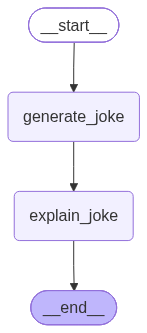

In [30]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "explain_joke")
graph.add_edge("explain_joke", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [31]:
config1 = {
    "configurable":{
        "thread_id": "1"
    }
}

output_state = workflow.invoke({"topic": "Quantum Physics"}, config=config1)
output_state

{'topic': 'Quantum Physics',
 'joke': '**Why did the quantum physicist bring a ladder to the lab?**\n\nBecause every time he tried to *measure* the particle’s position, it *jumped* to a higher energy level!',
 'explanation': '**Short answer**\n\nThe joke is a pun that mixes two very different ideas:\n\n| Physics idea | Everyday idea | How the joke connects them |\n|---------------|---------------|----------------------------|\n| Measuring a particle’s position changes its state and can make it “jump” to a different (higher) energy level. | A ladder is a tool you use to climb higher. | The physicist literally brings a ladder because the particle keeps “jumping” to a higher rung (energy level) every time he measures it. |\n\n---\n\n### 1. The'}

In [32]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Quantum Physics', 'joke': '**Why did the quantum physicist bring a ladder to the lab?**\n\nBecause every time he tried to *measure* the particle’s position, it *jumped* to a higher energy level!', 'explanation': '**Short answer**\n\nThe joke is a pun that mixes two very different ideas:\n\n| Physics idea | Everyday idea | How the joke connects them |\n|---------------|---------------|----------------------------|\n| Measuring a particle’s position changes its state and can make it “jump” to a different (higher) energy level. | A ladder is a tool you use to climb higher. | The physicist literally brings a ladder because the particle keeps “jumping” to a higher rung (energy level) every time he measures it. |\n\n---\n\n### 1. The'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05bb-3631-6113-8002-371db21d40a5'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-25T08:05:13.727799+0

In [33]:
list(workflow.get_state_history(config1))     # Works like a stack (LIFO)

[StateSnapshot(values={'topic': 'Quantum Physics', 'joke': '**Why did the quantum physicist bring a ladder to the lab?**\n\nBecause every time he tried to *measure* the particle’s position, it *jumped* to a higher energy level!', 'explanation': '**Short answer**\n\nThe joke is a pun that mixes two very different ideas:\n\n| Physics idea | Everyday idea | How the joke connects them |\n|---------------|---------------|----------------------------|\n| Measuring a particle’s position changes its state and can make it “jump” to a different (higher) energy level. | A ladder is a tool you use to climb higher. | The physicist literally brings a ladder because the particle keeps “jumping” to a higher rung (energy level) every time he measures it. |\n\n---\n\n### 1. The'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1a05bb-3631-6113-8002-371db21d40a5'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-25T08:05:13.727799+

In [34]:
config2 = {
    "configurable":{
        "thread_id": "2"
    }
}

output_state = workflow.invoke({"topic": "AI"}, config=config2)
output_state

{'topic': 'AI',
 'joke': 'Why did the AI bring a ladder to the data center?  \nBecause it heard the servers were *up* and it wanted to *scale* new heights!',
 'explanation': '**Why the joke works**\n\n| What the joke says | Literal meaning | Computing meaning |\n|--------------------|-----------------|-------------------|\n| “The servers were *up*” | The servers are standing on the floor of the data center, physically *up*. | In IT lingo “up” means the servers are running, healthy, and online. |\n| “It wanted to *scale* new heights!” | The AI wants to climb higher, literally scaling the racks with a ladder. | “Scale” in cloud/IT parlance means to increase capacity—add more servers, more compute power, more storage, etc. |\n\nSo the joke is a **word‑play (pun)** that mixes the everyday sense of “up” and “scale” with their technical meanings in a data‑center context.\n\n**Step‑by‑step explanation**\n\n1. **Data‑center context**  \n   - In a data center, servers are usually described as “

In [35]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'AI', 'joke': 'Why did the AI bring a ladder to the data center?  \nBecause it heard the servers were *up* and it wanted to *scale* new heights!', 'explanation': '**Why the joke works**\n\n| What the joke says | Literal meaning | Computing meaning |\n|--------------------|-----------------|-------------------|\n| “The servers were *up*” | The servers are standing on the floor of the data center, physically *up*. | In IT lingo “up” means the servers are running, healthy, and online. |\n| “It wanted to *scale* new heights!” | The AI wants to climb higher, literally scaling the racks with a ladder. | “Scale” in cloud/IT parlance means to increase capacity—add more servers, more compute power, more storage, etc. |\n\nSo the joke is a **word‑play (pun)** that mixes the everyday sense of “up” and “scale” with their technical meanings in a data‑center context.\n\n**Step‑by‑step explanation**\n\n1. **Data‑center context**  \n   - In a data center, servers are usu

In [36]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'AI', 'joke': 'Why did the AI bring a ladder to the data center?  \nBecause it heard the servers were *up* and it wanted to *scale* new heights!', 'explanation': '**Why the joke works**\n\n| What the joke says | Literal meaning | Computing meaning |\n|--------------------|-----------------|-------------------|\n| “The servers were *up*” | The servers are standing on the floor of the data center, physically *up*. | In IT lingo “up” means the servers are running, healthy, and online. |\n| “It wanted to *scale* new heights!” | The AI wants to climb higher, literally scaling the racks with a ladder. | “Scale” in cloud/IT parlance means to increase capacity—add more servers, more compute power, more storage, etc. |\n\nSo the joke is a **word‑play (pun)** that mixes the everyday sense of “up” and “scale” with their technical meanings in a data‑center context.\n\n**Step‑by‑step explanation**\n\n1. **Data‑center context**  \n   - In a data center, servers are us